# **Lab - 03** : Scikit-learn: Data Preprocessing and Model Performance Evaluation 

## Part A - Data Loading and Preprocessing with Scikit-learn

### Task 1 - Load and Understand the Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)


In [27]:
hotel_df = pd.read_csv('hotel_bookings.csv')

#### ● Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.


In [3]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
hotel_df.shape

(119390, 32)

In [5]:
hotel_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
hotel_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



#### ● Check the class distribution of is_canceled and use it as the target y.

In [7]:
# checking class distribution of is_canceled :

print("\nClass distribution:")
print(hotel_df["is_canceled"].value_counts())

print("\nClass distribution in percentage:")
print(hotel_df["is_canceled"].value_counts(normalize=True) * 100)
print('-' * 10)
# Create target variable y
y = hotel_df["is_canceled"]

print("\nTarget variable y:")
display(y.head())
print('-' * 10)

# Create X by removing the target column
X = hotel_df.drop(columns=["is_canceled"])

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


Class distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Class distribution in percentage:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64
----------

Target variable y:


0    0
1    0
2    0
3    0
4    0
Name: is_canceled, dtype: int64

----------

Shape of X: (119390, 31)
Shape of y: (119390,)


#### ● Create X from the remaining usable features.Identify numerical and categorical columns.

In [8]:
# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nNumerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumber of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))


Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Number of numerical columns: 19
Number of categorical columns: 12


C:\Users\rutup\AppData\Local\Temp\ipykernel_14404\3703879670.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()


### Task 2 - Missing Values, Leakage, and Outliers

#### ● Find the missing-value count and percentage for every column.

In [9]:
hotel_df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [10]:
# Find the number of missing values in every column
missing_count = hotel_df.isnull().sum()

# Find the percentage of missing values in every column
missing_percentage = (hotel_df.isnull().sum() / len(hotel_df)) * 100

# Combine both into one table
missing_data = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Sort by missing count, highest first
missing_data = missing_data.sort_values(
    by="Missing Count",
    ascending=False
)

# Display the result
display(missing_data)

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


#### ● Identify columns with very high missingness. Drop them only if justified and state the reason.

In [11]:
# the columns with the highest missingness is : company 

# Calculate missing-value percentage for every column
missing_percentage = (hotel_df.isnull().sum() / len(hotel_df)) * 100

# Display columns with missing values, sorted from highest to lowest
missing_data = pd.DataFrame({
    "Missing Count": hotel_df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_data = missing_data[missing_data["Missing Count"] > 0]
missing_data = missing_data.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_data)


# Identify columns with very high missingness
high_missing_columns = missing_data[
    missing_data["Missing Percentage"] > 50
].index.tolist()

print("Columns with more than 50% missing values:")
print(high_missing_columns)


# Drop columns with more than 50% missing values
hotel_df = hotel_df.drop(columns=high_missing_columns)

print("\nColumns dropped:")
print(high_missing_columns)

print("\nNew shape of dataset:")
print(hotel_df.shape)

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


Columns with more than 50% missing values:
['company']

Columns dropped:
['company']

New shape of dataset:
(119390, 31)


#### ● Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.

In [12]:
# Columns that directly reveal the final booking outcome
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

# Remove them from the dataset
hotel_df = hotel_df.drop(columns=leakage_columns)

# Check that they have been removed
print("Remaining columns:")
print(hotel_df.columns.tolist())

Remaining columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


#### ● Check selected numerical features for outliers using boxplots and/or the IQR method.

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


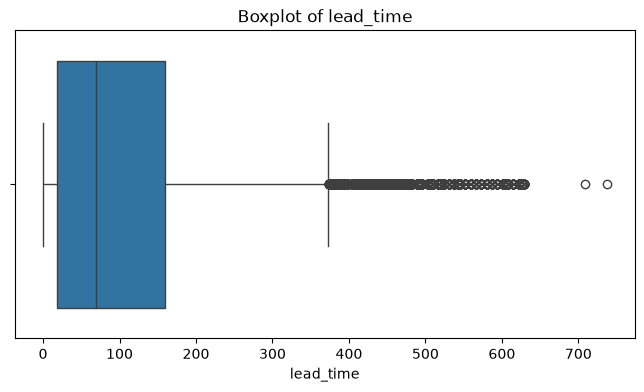

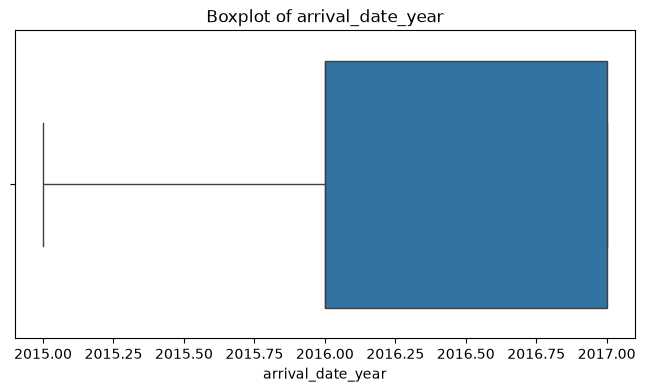

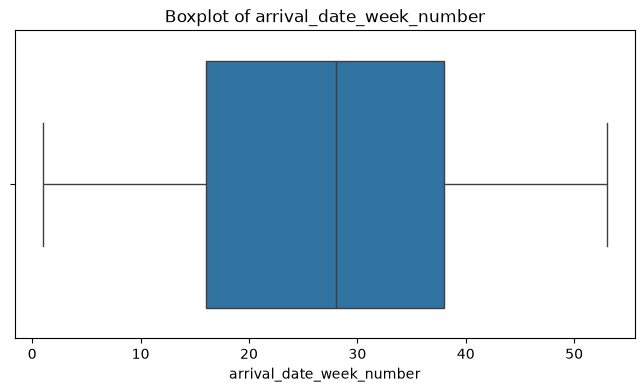

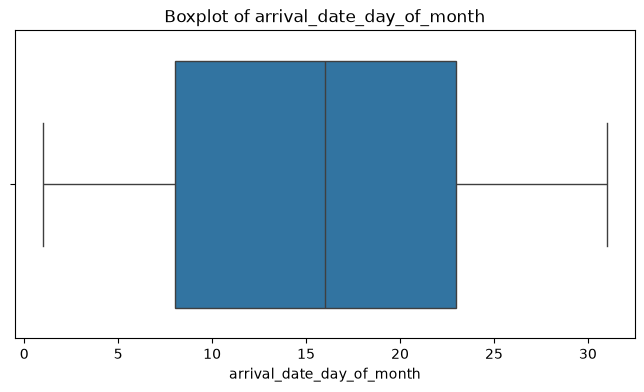

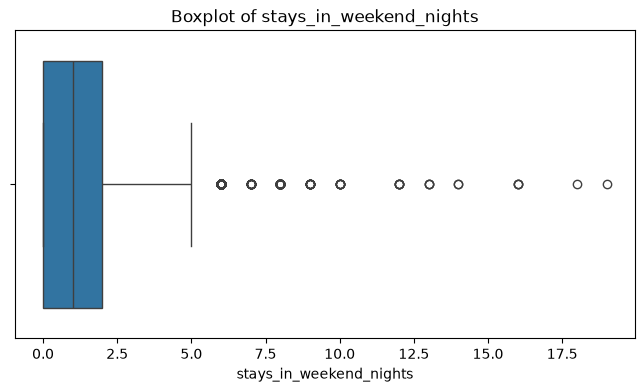

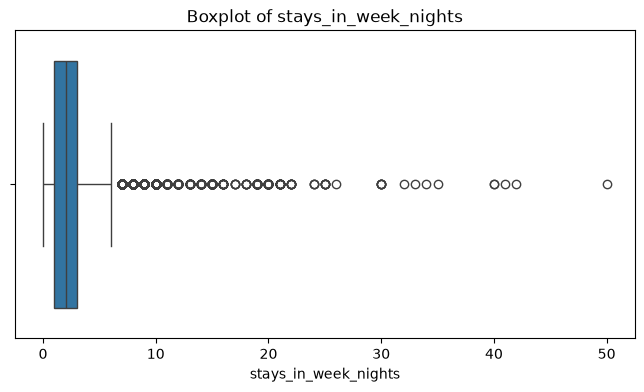

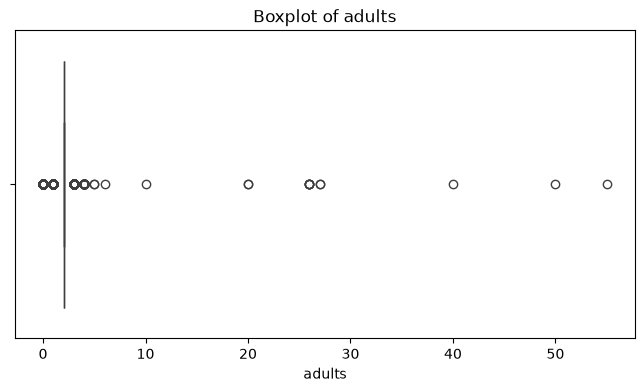

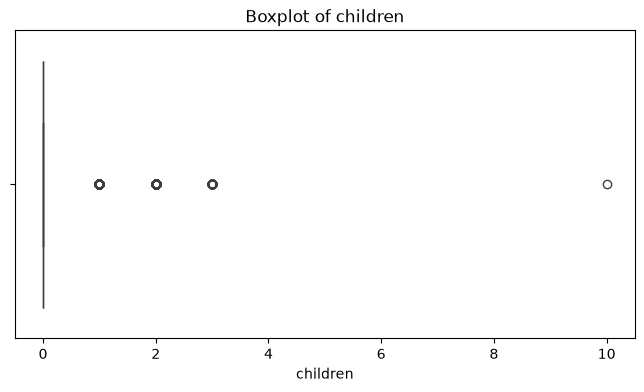

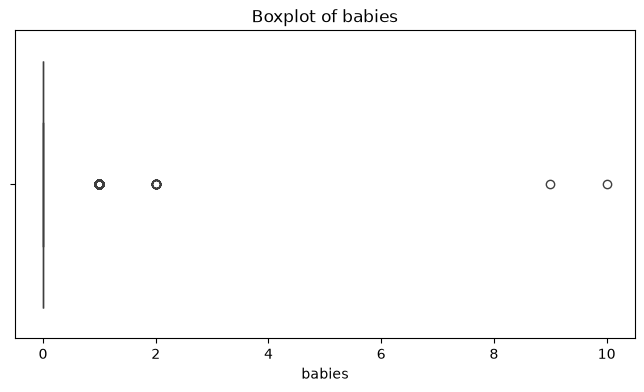

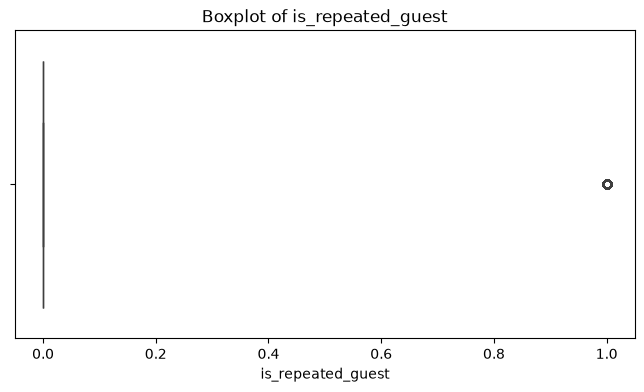

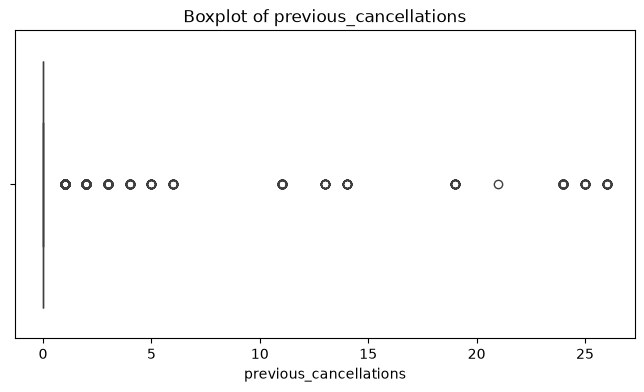

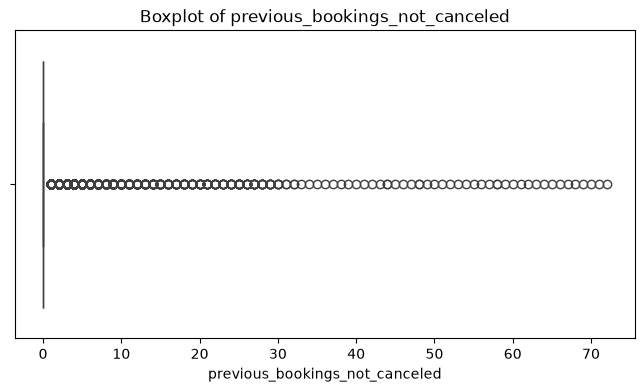

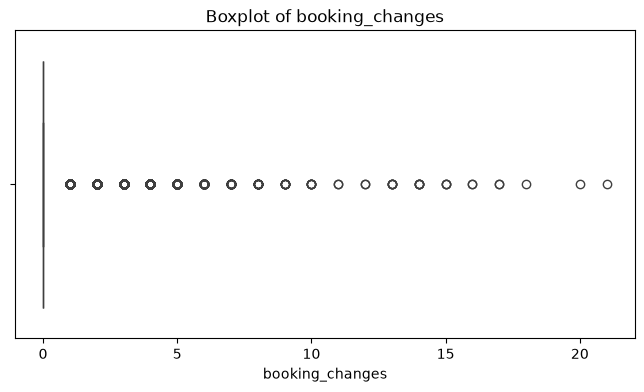

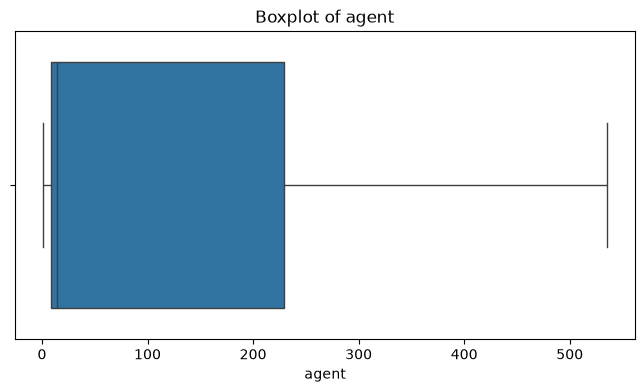

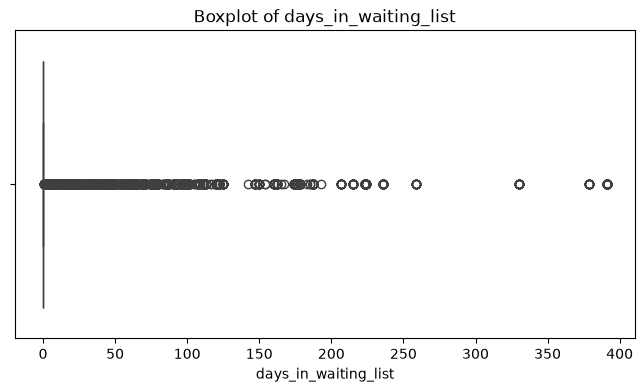

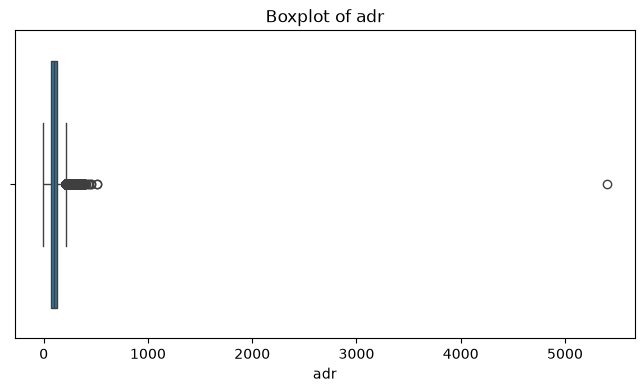

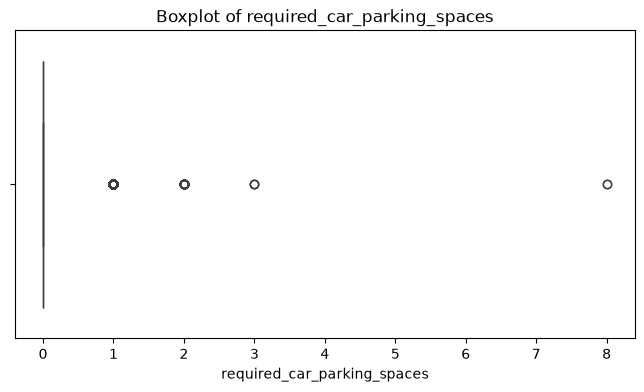

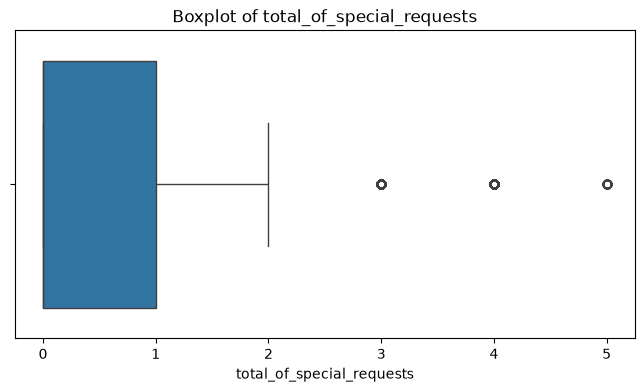

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
6,adults,2.00,2.0,0.00,2.000,2.000,29710,24.884831
12,booking_changes,0.00,0.0,0.00,0.000,0.000,18076,15.140297
7,children,0.00,0.0,0.00,0.000,0.000,8590,7.194907
16,required_car_parking_spaces,0.00,0.0,0.00,0.000,0.000,7416,6.211576
10,previous_cancellations,0.00,0.0,0.00,0.000,0.000,6484,5.430941
9,is_repeated_guest,0.00,0.0,0.00,0.000,0.000,3810,3.191222
15,adr,69.29,126.0,56.71,-15.775,211.065,3793,3.176983
14,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,3698,3.097412
11,previous_bookings_not_canceled,0.00,0.0,0.00,0.000,0.000,3620,3.032080
5,stays_in_week_nights,1.00,3.0,2.00,-2.000,6.000,3354,2.809281


In [13]:
# --------------------------------------------------
# STEP 1: Select numerical columns
# --------------------------------------------------

numerical_columns = hotel_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Remove the target variable from outlier analysis
numerical_features = [
    col for col in numerical_columns
    if col != "is_canceled"
]

print("Numerical features:")
print(numerical_features)


# --------------------------------------------------
# STEP 2: Create boxplots
# --------------------------------------------------

for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=hotel_df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


# --------------------------------------------------
# STEP 3: Detect outliers using IQR
# --------------------------------------------------

outlier_results = []

for col in numerical_features:

    Q1 = hotel_df[col].quantile(0.25)
    Q3 = hotel_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = hotel_df[
        (hotel_df[col] < lower_bound) |
        (hotel_df[col] > upper_bound)
    ]

    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(hotel_df)) * 100

    outlier_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })


# Convert results into a DataFrame
outlier_results = pd.DataFrame(outlier_results)

# Sort by number of outliers
outlier_results = outlier_results.sort_values(
    by="Outlier Count",
    ascending=False
)

display(outlier_results)

#### ● Remove only clear/extreme outliers and report how many rows were removed.

In [14]:
# --------------------------------------------------
# STEP 1: Check extreme values in important features
# --------------------------------------------------

print("Extreme values before removal:")

print("\nADR:")
print(hotel_df["adr"].describe())

print("\nAdults:")
print(hotel_df["adults"].describe())

print("\nChildren:")
print(hotel_df["children"].describe())

print("\nBabies:")
print(hotel_df["babies"].describe())


# --------------------------------------------------
# STEP 2: Record the number of rows before removal
# --------------------------------------------------

rows_before = len(hotel_df)


# --------------------------------------------------
# STEP 3: Remove clearly invalid/extreme observations
# --------------------------------------------------

hotel_df = hotel_df[
    (hotel_df["adr"] >= 0) &
    (hotel_df["adults"] > 0) &
    (hotel_df["children"] >= 0) &
    (hotel_df["babies"] >= 0)
]


# --------------------------------------------------
# STEP 4: Calculate how many rows were removed
# --------------------------------------------------

rows_after = len(hotel_df)

rows_removed = rows_before - rows_after

print("\nRows before removal:", rows_before)
print("Rows after removal:", rows_after)
print("Rows removed:", rows_removed)

Extreme values before removal:

ADR:
count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

Adults:
count    119390.000000
mean          1.856403
std           0.579261
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: adults, dtype: float64

Children:
count    119386.000000
mean          0.103890
std           0.398561
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: children, dtype: float64

Babies:
count    119390.000000
mean          0.007949
std           0.097436
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: babies, dtype: float64

Rows before removal: 119390
Rows after removal: 118982
Rows removed: 408


### Task 3 - Create Two Preprocessing Pipelines

#### ● Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for all experiments.

In [15]:
# --------------------------------------------------
# STEP 1: Create X and y
# --------------------------------------------------

y = hotel_df["is_canceled"]

X = hotel_df.drop(columns=["is_canceled"])


# --------------------------------------------------
# STEP 2: Split into training and testing data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# --------------------------------------------------
# STEP 3: Check the sizes
# --------------------------------------------------

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# --------------------------------------------------
# STEP 4: Check class distribution
# --------------------------------------------------

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Original X shape: (118982, 28)
Original y shape: (118982,)

X_train shape: (95185, 28)
X_test shape: (23797, 28)

y_train shape: (95185,)
y_test shape: (23797,)

Training target distribution:
is_canceled
0    62.925881
1    37.074119
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    62.9281
1    37.0719
Name: proportion, dtype: float64


#### ● For numerical columns, use KNNImputer(n_neighbors=5) for missing values.

In [16]:
# --------------------------------------------------
# STEP 1: Identify numerical columns
# --------------------------------------------------
numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

# --------------------------------------------------
# STEP 2: Create the KNN Imputer
# --------------------------------------------------

knn_imputer = KNNImputer(n_neighbors=5)

# --------------------------------------------------
# STEP 3: Fit the imputer ONLY on training data
# --------------------------------------------------

X_train[numerical_columns] = knn_imputer.fit_transform(
    X_train[numerical_columns]
)

# --------------------------------------------------
# STEP 4: Apply the same imputer to test data
# --------------------------------------------------

X_test[numerical_columns] = knn_imputer.transform(
    X_test[numerical_columns]
)

# --------------------------------------------------
# STEP 5: Check whether numerical missing values remain
# --------------------------------------------------

print("\nMissing numerical values in X_train:")
print(X_train[numerical_columns].isnull().sum())

print("\nMissing numerical values in X_test:")
print(X_test[numerical_columns].isnull().sum())

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Missing numerical values in X_train:
lead_time                         0
arrival_date_year                 0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
agent                             0
days_in_waiting_list              0
adr                         

#### ● For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore").

In [17]:
# --------------------------------------------------
# STEP 1: Identify categorical columns
# --------------------------------------------------

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)


# --------------------------------------------------
# STEP 2: Create the categorical imputer
# --------------------------------------------------

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)


# --------------------------------------------------
# STEP 3: Impute missing categorical values
# --------------------------------------------------

X_train[categorical_columns] = categorical_imputer.fit_transform(
    X_train[categorical_columns]
)

X_test[categorical_columns] = categorical_imputer.transform(
    X_test[categorical_columns]
)


# --------------------------------------------------
# STEP 4: Create OneHotEncoder
# --------------------------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)


# --------------------------------------------------
# STEP 5: Fit encoder ONLY on training data
# --------------------------------------------------

X_train_encoded = encoder.fit_transform(
    X_train[categorical_columns]
)


# --------------------------------------------------
# STEP 6: Transform test data using same encoder
# --------------------------------------------------

X_test_encoded = encoder.transform(
    X_test[categorical_columns]
)


# --------------------------------------------------
# STEP 7: Check the result
# --------------------------------------------------

print("\nOriginal number of categorical columns:",
      len(categorical_columns))

print("Encoded training shape:",
      X_train_encoded.shape)

print("Encoded testing shape:",
      X_test_encoded.shape)

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


C:\Users\rutup\AppData\Local\Temp\ipykernel_14404\3431517882.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(



Original number of categorical columns: 10
Encoded training shape: (95185, 229)
Encoded testing shape: (23797, 229)


#### ● Pipeline A: KNNImputer + StandardScaler for numerical features.

In [18]:
# --------------------------------------------------
# STEP 1: Identify numerical columns
# --------------------------------------------------

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)


# --------------------------------------------------
# STEP 2: Create Pipeline A
# --------------------------------------------------

pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])


# --------------------------------------------------
# STEP 3: Fit and transform training data
# --------------------------------------------------

X_train_num_A = pipeline_A.fit_transform(
    X_train[numerical_columns]
)


# --------------------------------------------------
# STEP 4: Transform test data
# --------------------------------------------------

X_test_num_A = pipeline_A.transform(
    X_test[numerical_columns]
)


# --------------------------------------------------
# STEP 5: Check the result
# --------------------------------------------------

print("\nOriginal numerical features:", len(numerical_columns))

print("X_train numerical shape:", X_train_num_A.shape)
print("X_test numerical shape:", X_test_num_A.shape)

print("\nFirst 5 rows of transformed training data:")
print(X_train_num_A[:5])

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Original numerical features: 18
X_train numerical shape: (95185, 18)
X_test numerical shape: (23797, 18)

First 5 rows of transformed training data:
[[-0.34723908  1.19236709 -1.55346473 -0.77235601  0.07565276  0.26385324
   0.24052815 -0.25750532 -0.08092033 -0.17958875 -0.10353236 -0.08996788
  -0.342922   -0.75456373 -0.13184137 -0.5343912  -0.25618971  0.54152074]
 [ 2.28369687  1.19236709 -0.37694152 -1.45506275  1.08123971 -0.79095025
   0.24052815 -0.25750532 -0.08092033 -0.17958875 -0.10353236 -0.08996788
  -0.342922   -0.78228203 -0.13184137 -0.23603355 -0.25618971 -0.71978821]
 [-0.83410

#### ● Pipeline B: KNNImputer + MinMaxScaler for numerical features.

In [19]:
# --------------------------------------------------
# STEP 1: Identify numerical columns
# --------------------------------------------------

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)


# --------------------------------------------------
# STEP 2: Create Pipeline B
# --------------------------------------------------

pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])


# --------------------------------------------------
# STEP 3: Fit and transform training data
# --------------------------------------------------

X_train_num_B = pipeline_B.fit_transform(
    X_train[numerical_columns]
)


# --------------------------------------------------
# STEP 4: Transform test data
# --------------------------------------------------

X_test_num_B = pipeline_B.transform(
    X_test[numerical_columns]
)


# --------------------------------------------------
# STEP 5: Check the result
# --------------------------------------------------

print("\nOriginal numerical features:", len(numerical_columns))

print("X_train numerical shape:", X_train_num_B.shape)
print("X_test numerical shape:", X_test_num_B.shape)

print("\nFirst 5 rows of transformed training data:")
print(X_train_num_B[:5])

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Original numerical features: 18
X_train numerical shape: (95185, 18)
X_test numerical shape: (23797, 18)

First 5 rows of transformed training data:
[[0.09090909 1.         0.09615385 0.26666667 0.05263158 0.06
  0.01851852 0.         0.         0.         0.         0.
  0.         0.01498127 0.         0.01385185 0.         0.2       ]
 [0.47218453 1.         0.40384615 0.06666667 0.10526316 0.02
  0.01851852 0.         0.         0.         0.         0.
  0.         0.0093633  0.         0.01666667 0.         0.        ]
 [0.02035278 0.5        0.71153846 0.4        0.         0.04
  0.01851852

#### ● Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [20]:
# --------------------------------------------------
# STEP 1: Identify numerical and categorical columns
# --------------------------------------------------

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)


# --------------------------------------------------
# STEP 2: Create numerical preprocessing pipeline
# --------------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])


# --------------------------------------------------
# STEP 3: Create categorical preprocessing pipeline
# --------------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# --------------------------------------------------
# STEP 4: Combine both pipelines using ColumnTransformer
# --------------------------------------------------

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])


# --------------------------------------------------
# STEP 5: Fit preprocessing ONLY on training data
# --------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)


# --------------------------------------------------
# STEP 6: Transform test data using the fitted
#         preprocessor
# --------------------------------------------------

X_test_processed = preprocessor.transform(X_test)


# --------------------------------------------------
# STEP 7: Check the results
# --------------------------------------------------

print("\nOriginal X_train shape:")
print(X_train.shape)

print("\nProcessed X_train shape:")
print(X_train_processed.shape)

print("\nOriginal X_test shape:")
print(X_test.shape)

print("\nProcessed X_test shape:")
print(X_test_processed.shape)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


C:\Users\rutup\AppData\Local\Temp\ipykernel_14404\2633530406.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(



Original X_train shape:
(95185, 28)

Processed X_train shape:
(95185, 247)

Original X_test shape:
(23797, 28)

Processed X_test shape:
(23797, 247)


## Part B - Model Training and Performance Evaluation

### Task 4 - Train Two Classification Models

#### ● Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.

In [21]:
# --------------------------------------------------
# Pipeline A: KNNImputer + StandardScaler
#                    +
#              LogisticRegression
# --------------------------------------------------

logistic_A = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])


# --------------------------------------------------
# Train Logistic Regression using Pipeline A
# --------------------------------------------------

logistic_A.fit(X_train, y_train)


# --------------------------------------------------
# Pipeline B: KNNImputer + MinMaxScaler
#                    +
#              LogisticRegression
# --------------------------------------------------

# Create numerical pipeline for Pipeline B

numerical_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])


# Create categorical pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Combine Pipeline B numerical and categorical processing

preprocessor_B = ColumnTransformer([
    ("numerical", numerical_pipeline_B, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])


# --------------------------------------------------
# Pipeline B + Logistic Regression
# --------------------------------------------------

logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])


# --------------------------------------------------
# Train Logistic Regression using Pipeline B
# --------------------------------------------------

logistic_B.fit(X_train, y_train)


print("Both Logistic Regression models have been trained successfully.")

Both Logistic Regression models have been trained successfully.


#### ● Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.

In [22]:
# ==================================================
# PIPELINE A
# KNNImputer + StandardScaler + Decision Tree
# ==================================================

numerical_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_pipeline_A = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_A = ColumnTransformer([
    ("numerical", numerical_pipeline_A, numerical_columns),
    ("categorical", categorical_pipeline_A, categorical_columns)
])

decision_tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])


# --------------------------------------------------
# Train Decision Tree using Pipeline A
# --------------------------------------------------

decision_tree_A.fit(X_train, y_train)


# ==================================================
# PIPELINE B
# KNNImputer + MinMaxScaler + Decision Tree
# ==================================================

numerical_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

categorical_pipeline_B = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_B = ColumnTransformer([
    ("numerical", numerical_pipeline_B, numerical_columns),
    ("categorical", categorical_pipeline_B, categorical_columns)
])

decision_tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])


# --------------------------------------------------
# Train Decision Tree using Pipeline B
# --------------------------------------------------

decision_tree_B.fit(X_train, y_train)


print("Both Decision Tree models have been trained successfully.")

Both Decision Tree models have been trained successfully.


### Task 5 - Evaluate and Compare the Four Results

#### ● For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.

In [23]:
# --------------------------------------------------
# STEP 1: Put all trained models in one dictionary
# --------------------------------------------------

experiments = {
    "Logistic Regression - Pipeline A": logistic_A,
    "Logistic Regression - Pipeline B": logistic_B,
    "Decision Tree - Pipeline A": decision_tree_A,
    "Decision Tree - Pipeline B": decision_tree_B
}


# --------------------------------------------------
# STEP 2: Create an empty list to store results
# --------------------------------------------------

results = []


# --------------------------------------------------
# STEP 3: Calculate metrics for every experiment
# --------------------------------------------------

for name, model in experiments.items():

    # Training predictions
    y_train_pred = model.predict(X_train)

    # Testing predictions
    y_test_pred = model.predict(X_test)

    # Training accuracy
    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    # Testing accuracy
    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    # Precision
    precision = precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # F1-score
    f1 = f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # Store results
    results.append({
        "Experiment": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


# --------------------------------------------------
# STEP 4: Convert results into a DataFrame
# --------------------------------------------------

results_df = pd.DataFrame(results)


# --------------------------------------------------
# STEP 5: Display results
# --------------------------------------------------

print(results_df.round(4))

                         Experiment  Training Accuracy  Testing Accuracy  \
0  Logistic Regression - Pipeline A             0.8189            0.8181   
1  Logistic Regression - Pipeline B             0.8131            0.8133   
2        Decision Tree - Pipeline A             0.9963            0.8614   
3        Decision Tree - Pipeline B             0.9963            0.8613   

   Precision  Recall  F1-score  
0     0.8119  0.6630    0.7299  
1     0.8092  0.6495    0.7206  
2     0.8129  0.8134    0.8131  
3     0.8124  0.8138    0.8131  


#### ● Create a final comparison table containing all four model-pipeline combinations.

In [24]:
# --------------------------------------------------
# Final comparison table
# --------------------------------------------------

comparison_table = results_df.copy()

# Round metric values for easier reading
comparison_table[
    ["Training Accuracy",
     "Testing Accuracy",
     "Precision",
     "Recall",
     "F1-score"]
] = comparison_table[
    ["Training Accuracy",
     "Testing Accuracy",
     "Precision",
     "Recall",
     "F1-score"]
].round(4)

# Display the final comparison table
print(comparison_table.to_string(index=False))

                      Experiment  Training Accuracy  Testing Accuracy  Precision  Recall  F1-score
Logistic Regression - Pipeline A             0.8189            0.8181     0.8119  0.6630    0.7299
Logistic Regression - Pipeline B             0.8131            0.8133     0.8092  0.6495    0.7206
      Decision Tree - Pipeline A             0.9963            0.8614     0.8129  0.8134    0.8131
      Decision Tree - Pipeline B             0.9963            0.8613     0.8124  0.8138    0.8131


#### ● Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result.

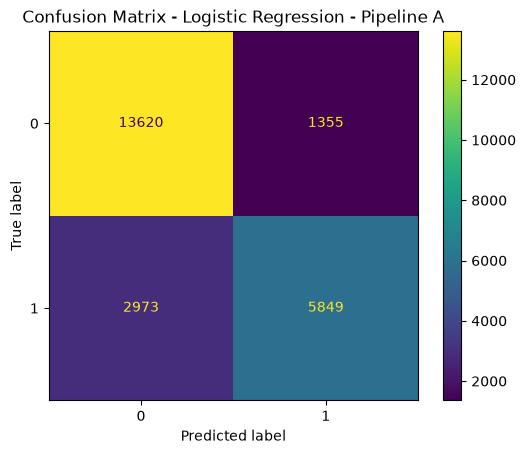

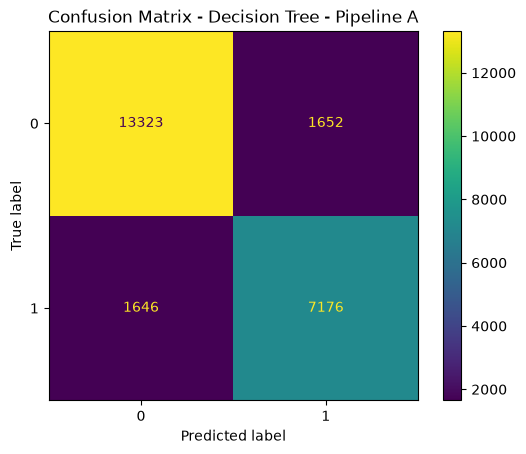

Best Logistic Regression: Logistic Regression - Pipeline A
Best Decision Tree: Decision Tree - Pipeline A


In [25]:
# --------------------------------------------------
# STEP 1: Find the best Logistic Regression result
# --------------------------------------------------

logistic_results = comparison_table[
    comparison_table["Experiment"].str.contains("Logistic Regression")
]

best_logistic_name = logistic_results.loc[
    logistic_results["F1-score"].idxmax(),
    "Experiment"
]


# --------------------------------------------------
# STEP 2: Find the best Decision Tree result
# --------------------------------------------------

tree_results = comparison_table[
    comparison_table["Experiment"].str.contains("Decision Tree")
]

best_tree_name = tree_results.loc[
    tree_results["F1-score"].idxmax(),
    "Experiment"
]


# --------------------------------------------------
# STEP 3: Get the corresponding trained models
# --------------------------------------------------

best_models = {
    "Logistic Regression": experiments[best_logistic_name],
    "Decision Tree": experiments[best_tree_name]
}


# --------------------------------------------------
# STEP 4: Plot confusion matrix for Logistic Regression
# --------------------------------------------------

logistic_model = best_models["Logistic Regression"]

y_test_pred_logistic = logistic_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_logistic
)

plt.title(f"Confusion Matrix - {best_logistic_name}")
plt.show()


# --------------------------------------------------
# STEP 5: Plot confusion matrix for Decision Tree
# --------------------------------------------------

tree_model = best_models["Decision Tree"]

y_test_pred_tree = tree_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_tree
)

plt.title(f"Confusion Matrix - {best_tree_name}")
plt.show()


# --------------------------------------------------
# STEP 6: Print which models were selected
# --------------------------------------------------

print("Best Logistic Regression:", best_logistic_name)
print("Best Decision Tree:", best_tree_name)

#### ● Use the train-test performance difference to comment briefly on possible overfitting.

In [26]:
# --------------------------------------------------
# Calculate the train-test performance difference
# --------------------------------------------------

comparison_table["Train-Test Difference"] = (
    comparison_table["Training Accuracy"]
    - comparison_table["Testing Accuracy"]
)

print(comparison_table[
    [
        "Experiment",
        "Training Accuracy",
        "Testing Accuracy",
        "Train-Test Difference"
    ]
].round(4))


# --------------------------------------------------
# Comment on possible overfitting
# --------------------------------------------------

print("\nOverfitting Analysis:\n")

for _, row in comparison_table.iterrows():

    difference = row["Train-Test Difference"]

    if difference > 0.10:
        comment = "Large gap → strong indication of possible overfitting."

    elif difference > 0.05:
        comment = "Moderate gap → possible overfitting."

    else:
        comment = "Small gap → no strong indication of overfitting."

    print(f"{row['Experiment']}: {comment}")

                         Experiment  Training Accuracy  Testing Accuracy  \
0  Logistic Regression - Pipeline A             0.8189            0.8181   
1  Logistic Regression - Pipeline B             0.8131            0.8133   
2        Decision Tree - Pipeline A             0.9963            0.8614   
3        Decision Tree - Pipeline B             0.9963            0.8613   

   Train-Test Difference  
0                 0.0008  
1                -0.0002  
2                 0.1349  
3                 0.1350  

Overfitting Analysis:

Logistic Regression - Pipeline A: Small gap → no strong indication of overfitting.
Logistic Regression - Pipeline B: Small gap → no strong indication of overfitting.
Decision Tree - Pipeline A: Large gap → strong indication of possible overfitting.
Decision Tree - Pipeline B: Large gap → strong indication of possible overfitting.
